In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

In [51]:
path = "../dataset/AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt"
df = pd.read_csv(path)

In [52]:

# Compute derived columns
df['arrival_time'] = df['end_timestamp'] - df['duration']
df.sort_values(by='arrival_time', inplace=True)
hour_trace = 4
df['trace_id'] = (df['arrival_time'] // (hour_trace * 3600)).astype(int)
df['arrival_time_norm'] = df['arrival_time'] - (df['trace_id'] * hour_trace * 3600)

In [53]:

# Categories: (min_req, max_req, num_func, cov_min, cov_max)
categories = [
    (40, 100, 2, 0, 0.4),
    (100, 250, 3, 1, 3),
    (200, 250, 2, 2, 4)
]

min_count = 2
best_groups = []
used_funcs = set()

for cat_idx, (min_req, max_req, num_func, cov_min, cov_max) in enumerate(categories):
    best_score = -1
    best_group = None

    for trace_id in df['trace_id'].unique():
        trace = df[df['trace_id'] == trace_id]
        func_counts = trace['func'].value_counts()
        candidate_funcs = func_counts[
            (func_counts >= min_req) & (func_counts <= max_req)
        ].index.tolist()

        # Exclude already used functions
        candidate_funcs = [f for f in candidate_funcs if f not in used_funcs]

        if len(candidate_funcs) < num_func:
            continue

        for funcs in combinations(candidate_funcs, num_func):
            covs = []
            valid = True

            for f in funcs:
                times = trace[trace['func'] == f]['arrival_time_norm'].sort_values().values
                if len(times) < 2:
                    valid = False
                    break
                gaps = np.diff(times)
                if len(gaps) < min_count or np.mean(gaps) == 0:
                    valid = False
                    break
                cov = np.std(gaps) / np.mean(gaps)
                covs.append(cov)

            if not valid:
                continue

            avg_cov = np.mean(covs)

            if cov_min < avg_cov < cov_max and avg_cov > best_score:
                best_score = avg_cov
                best_group = {
                    'category': cat_idx + 1,
                    'trace_id': trace_id,
                    'functions': list(funcs),
                    'avg_cov': avg_cov
                }

    if best_group:
        best_groups.append(best_group)
        used_funcs.update(best_group['functions'])  # Mark selected functions as used

# Final result
result_df = pd.DataFrame(best_groups)
print(result_df)


   category  trace_id                                          functions  \
0         1        59  [1f33077bb2db73fd76a51e40e43f20173e3f038dd3f37...   
1         2        52  [9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1f...   
2         3         3  [313c03f53a0d31f70aec25f62efb33e7dd779725ca4af...   

    avg_cov  
0  0.399792  
1  2.994437  
2  3.708413  


In [41]:
# # Categories (min_req, max_req, num_func)
# categories = [
#     (40, 100, 2, 0, 0.4),     # Category 1: CoV in (1, 2)
#     (100, 250, 3, 1, 3),    # Category 2: CoV in (2, 3)
#     (200, 250,2, 2, 4)     # Category 3: CoV in (3, 4)
# ]

# min_count = 2
# best_groups = []

# for cat_idx, (min_req, max_req, num_func, cov_min, cov_max) in enumerate(categories):
#     best_score = -1
#     best_group = None

#     for trace_id in df['trace_id'].unique():
#         trace = df[df['trace_id'] == trace_id]
#         func_counts = trace['func'].value_counts()
#         candidate_funcs = func_counts[
#             (func_counts >= min_req) & (func_counts <= max_req)
#         ].index.tolist()
        
#         if len(candidate_funcs) < num_func:
#             continue

#         for funcs in combinations(candidate_funcs, num_func):
#             covs = []
#             valid = True

#             for f in funcs:
#                 times = trace[trace['func'] == f]['arrival_time_norm'].sort_values().values
#                 if len(times) < 2:
#                     valid = False
#                     break
#                 gaps = np.diff(times)
#                 if len(gaps) < min_count or np.mean(gaps) == 0:
#                     valid = False
#                     break
#                 cov = np.std(gaps) / np.mean(gaps)
#                 covs.append(cov)

#             if not valid:
#                 continue

#             avg_cov = np.mean(covs)

#             # Apply category-specific CoV condition
#             if cov_min < avg_cov < cov_max and avg_cov > best_score:
#                 best_score = avg_cov
#                 best_group = {
#                     'category': cat_idx + 1,
#                     'trace_id': trace_id,
#                     'functions': list(funcs),
#                     'avg_cov': avg_cov
#                 }

#     if best_group:
#         best_groups.append(best_group)

# # Final result
# result_df = pd.DataFrame(best_groups)
# print(result_df)


   category  trace_id                                          functions  \
0         1        59  [1f33077bb2db73fd76a51e40e43f20173e3f038dd3f37...   
1         2        28  [9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1f...   
2         3        14  [313c03f53a0d31f70aec25f62efb33e7dd779725ca4af...   

    avg_cov  
0  0.399792  
1  2.983221  
2  3.913985  


/tmp/ipykernel_201126/4029340866.py:45: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


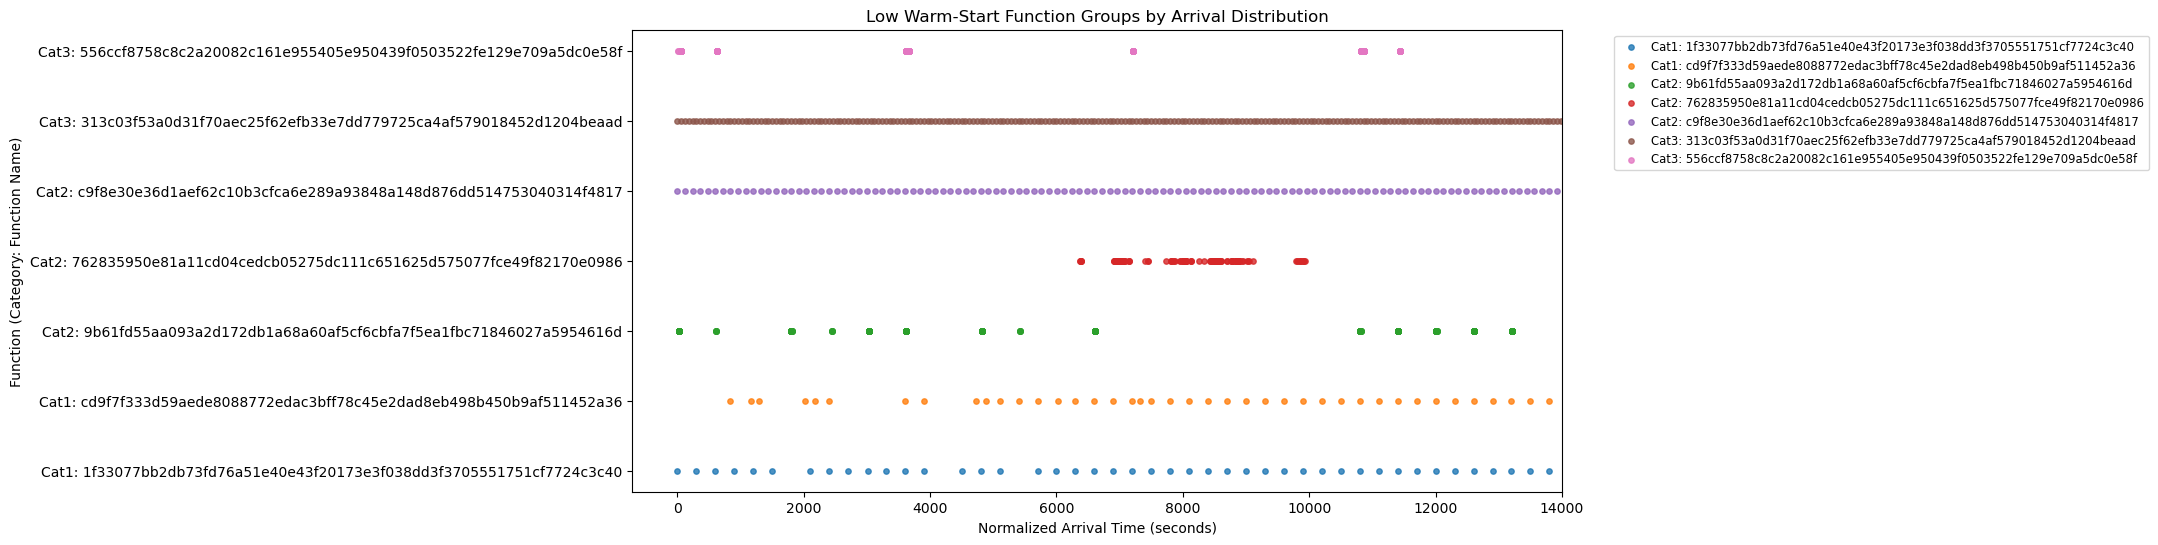

In [54]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6))

all_funcs = []
all_func_colors = {}
colors = plt.cm.tab10.colors
color_idx = 0

for _, entry in result_df.iterrows():
    trace_id = entry['trace_id']
    cat = entry['category']
    # if cat != 3:
    #     continue
    funcs = entry['functions']
    cat_color = colors[cat % len(colors)]
    for func in funcs:
        func_label = f"Cat{cat}: {func}"
        all_funcs.append(func_label)
        all_func_colors[func_label] = colors[color_idx % len(colors)]
        color_idx += 1
        func_df = df[(df['trace_id'] == trace_id) & (df['func'] == func)]
        plt.scatter(
            func_df['arrival_time_norm'],
            [func_label] * len(func_df),
            s=15,
            color=all_func_colors[func_label],
            label=func_label,
            alpha=0.8
        )


# Optional: Set max x-axis range
plt.xlim(right=14000)

# Deduplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.xlabel("Normalized Arrival Time (seconds)")
plt.ylabel("Function (Category: Function Name)")
plt.title("Low Warm-Start Function Groups by Arrival Distribution")
plt.tight_layout()
plt.show()


In [55]:
data = ['alexnet', 'efficientnet', 'bert', 'distilgpt2', 'resnet50', 'googlenet', 'inception']
i = 0 
res = []
name_header = ['func','trace_id','category_id','id','memory','file_path']
for l in best_groups:
    total_subset = len(l['functions'])
    
    for k in range(0,total_subset):
        temp = []
        trace_id = l['trace_id']
        category_id = l['category']
        func = data[i]
        memory = 1024
        file_path = data[i]+".py"
        id_val = l['functions'][k]
        i += 1
        res.append([func, trace_id, category_id, id_val, memory, file_path])

res_df = pd.DataFrame(res,columns=name_header)
func_dict = res_df.set_index('id')['func'].to_dict()
func_dict

{'1f33077bb2db73fd76a51e40e43f20173e3f038dd3f3705551751cf7724c3c40': 'alexnet',
 'cd9f7f333d59aede8088772edac3bff78c45e2dad8eb498b450b9af511452a36': 'efficientnet',
 '9b61fd55aa093a2d172db1a68a60af5cf6cbfa7f5ea1fbc71846027a5954616d': 'bert',
 '762835950e81a11cd04cedcb05275dc111c651625d575077fce49f82170e0986': 'distilgpt2',
 'c9f8e30e36d1aef62c10b3cfca6e289a93848a148d876dd514753040314f4817': 'resnet50',
 '313c03f53a0d31f70aec25f62efb33e7dd779725ca4af579018452d1204beaad': 'googlenet',
 '556ccf8758c8c2a20082c161e955405e950439f0503522fe129e709a5dc0e58f': 'inception'}

In [56]:
best_df_list = []

for _, entry in result_df.iterrows():
    trace_id = entry['trace_id']
    funcs = entry['functions']
    filtered = df[(df['trace_id'] == trace_id) & (df['func'].isin(funcs))]
    best_df_list.append(filtered)

# Concatenate all the filtered DataFrames
best_df = pd.concat(best_df_list, ignore_index=True)

# Optional: Sort by trace_id and arrival_time_norm for convenience
best_df = best_df.sort_values(by=['trace_id', 'func', 'arrival_time_norm']).reset_index(drop=True)

# Corrected normalization of arrival_time (if needed again)
best_df['arrival_time'] = best_df['arrival_time_norm']




In [57]:
best_df['func_id'] = best_df['func'].map(func_dict)
best_df

,app,func,end_timestamp,duration,arrival_time,trace_id,arrival_time_norm,func_id
0,734272c01926d19690e5ec308bab64ef97950b75b1c758...,313c03f53a0d31f70aec25f62efb33e7dd779725ca4af5...,43208.399459,8.391,0.008459,3,0.008459,googlenet
1,734272c01926d19690e5ec308bab64ef97950b75b1c758...,313c03f53a0d31f70aec25f62efb33e7dd779725ca4af5...,43260.712550,0.709,60.003550,3,60.003550,googlenet
2,734272c01926d19690e5ec308bab64ef97950b75b1c758...,313c03f53a0d31f70aec25f62efb33e7dd779725ca4af5...,43320.223469,0.224,119.999469,3,119.999469,googlenet
3,734272c01926d19690e5ec308bab64ef97950b75b1c758...,313c03f53a0d31f70aec25f62efb33e7dd779725ca4af5...,43380.201539,0.176,180.025539,3,180.025539,googlenet
4,734272c01926d19690e5ec308bab64ef97950b75b1c758...,313c03f53a0d31f70aec25f62efb33e7dd779725ca4af5...,43440.191525,0.176,240.015525,3,240.015525,googlenet
...,...,...,...,...,...,...,...,...
1037,85479ef37b5dc75dd5aeca3bab499129b97a134dac5d74...,cd9f7f333d59aede8088772edac3bff78c45e2dad8eb49...,862582.194902,82.135,12900.059902,59,12900.059902,efficientnet
1038,85479ef37b5dc75dd5aeca3bab499129b97a134dac5d74...,cd9f7f333d59aede8088772edac3bff78c45e2dad8eb49...,862861.620173,61.602,13200.018173,59,13200.018173,efficientnet
1039,85479ef37b5dc75dd5aeca3bab499129b97a134dac5d74...,cd9f7f333d59aede8088772edac3bff78c45e2dad8eb49...,863167.028921,67.005,13500.023921,59,13500.023921,efficientnet
1040,85479ef37b5dc75dd5aeca3bab499129b97a134dac5d74...,cd9f7f333d59aede8088772edac3bff78c45e2dad8eb49...,863459.845549,59.817,13800.028549,59,13800.028549,efficientnet


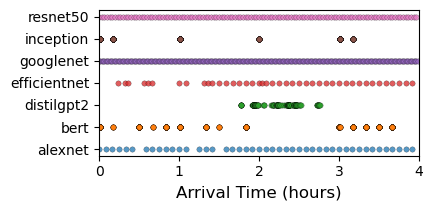

In [58]:
import matplotlib.pyplot as plt
import itertools

# Convert seconds to hours for x-axis
best_df['arrival_time_hr'] = best_df['arrival_time'] / 3600.0

# Marker styles to cycle through
markers = itertools.cycle(('o', 's', 'D', '^', 'v', 'P', '*'))

plt.figure(figsize=(4.5, 2.2))

# Plot each function group with style
for func_id, group in best_df.groupby('func_id'):
    plt.scatter(
        group['arrival_time_hr'],
        [func_id]*len(group),
        s=15,
        alpha=0.75,
        edgecolors='k',
        linewidths=0.2
    )

plt.xlabel("Arrival Time (hours)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlim(0, 4)
# plt.grid(True, linestyle='--', linewidth=0.4)
plt.tight_layout()
plt.show()

In [59]:
category_counts = best_df['func_id'].value_counts().sort_index()
category_counts

func_id
alexnet          45
bert            241
distilgpt2      146
efficientnet     42
googlenet       240
inception       208
resnet50        120
Name: count, dtype: int64

In [60]:
best_df = best_df.sort_values(by='arrival_time', ascending=True)

res_df.to_csv('../dataset/hybrid_gen_functions.csv', index=False)
best_df.to_csv('../dataset/hybrid_gen_df.csv', index=False)